# 07. 데이터 건전성 분석 (Bot Detection)

GitHub Archive 데이터에는 CI/CD 봇, GitHub Actions, 자동화 스크립트 등 **사람이 아닌 유저**가 다수 포함되어 있습니다.
봇이 포함된 상태에서 Retention이나 DAU를 계산하면 지표가 왜곡될 수 있습니다.

이 노트북에서는:
1. **봇 유저 식별** — 이상치 탐지 (활동량, 이벤트 패턴, 활동 일수 vs 이벤트 수 비율)
2. **봇 의심 유저 특성 분석** — 어떤 이벤트 타입이 많은지, 활동 패턴
3. **봇 제거 전/후 지표 비교** — Retention, WAU, Stickiness 변화
4. **봇 필터링 기준 제안** — 실무에서 적용할 수 있는 규칙

## 1. 데이터 로드 & 유저 요약 통계

In [ ]:
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

import sys; sys.path.insert(0, str(Path("../../src")))
from gharchive.transform import optimize_types, user_activity_summary

DATA_DIR = Path("/Users/kakao/bda-2/data/daily_agg")

frames = []
for path in sorted(DATA_DIR.glob("*.parquet")):
    df_part = pd.read_parquet(path)
    df_part["date"] = pd.to_datetime(path.stem, format="%Y%m%d")
    frames.append(df_part)

df = optimize_types(pd.concat(frames, ignore_index=True))
df["week"] = df["date"].dt.to_period("W-SAT").dt.start_time
weeks = sorted(df["week"].unique())

# 유저별 요약 통계
user_stats = user_activity_summary(df)
user_stats["events_per_day"] = user_stats["total_events"] / user_stats["active_days"]

print(f"Loaded: {len(df):,} rows, {df['date'].nunique()} days, {df['actor_id'].nunique():,} users")
print(f"\n유저별 총 이벤트 수 분포:")
print(user_stats["total_events"].describe().to_string())
print(f"\n유저별 일평균 이벤트 수 분포:")
print(user_stats["events_per_day"].describe().to_string())

## 2. 봇 의심 유저 식별

봇을 탐지하기 위해 여러 신호를 조합합니다:

| 신호 | 근거 |
|------|------|
| **일평균 이벤트 수 극단치** | 사람이 하루에 수천 개 이벤트를 만들기는 어려움 |
| **이벤트 타입 편중** | 봇은 보통 1~2개 타입만 반복 (PushEvent, CreateEvent 등) |
| **활동 일수 vs 이벤트 수 비율** | 매일 출현하면서 이벤트가 극도로 많으면 봇 가능성 높음 |
| **이벤트 타입 수 대비 활동량** | 봇은 다양한 타입을 쓰지 않음 |

### 2-1. 이상치 탐지: 활동량 분포

In [2]:
%%time
# 유저별 추가 피처 계산
# 이벤트 타입 수
type_counts = df.groupby("actor_id")["type"].nunique().rename("n_event_types")
user_stats = user_stats.merge(type_counts, on="actor_id")

# 활동 일수 비율 (35일 중 몇 일 활동했는가)
total_days = df["date"].nunique()
user_stats["active_day_ratio"] = user_stats["active_days"] / total_days

print(f"총 관측 기간: {total_days}일")
print(f"\n이벤트 타입 수 분포:")
print(user_stats["n_event_types"].value_counts().sort_index().to_string())

# 극단적 유저 확인
thresholds = [100, 500, 1000, 5000, 10000]
print("\n=== 일평균 이벤트 수 기준 유저 수 ===")
for t in thresholds:
    n = (user_stats["events_per_day"] >= t).sum()
    pct = n / len(user_stats) * 100
    print(f"  >= {t:>6}/day: {n:>8,} ({pct:.3f}%)")

총 관측 기간: 42일

이벤트 타입 수 분포:
n_event_types
1     4271382
2     2384525
3      659351
4      283619
5      131667
6       76160
7       47402
8       29827
9       13118
10       4509
11       1185
12        171
13         26
14          4

=== 일평균 이벤트 수 기준 유저 수 ===
  >=    100/day:    5,378 (0.068%)
  >=    500/day:      757 (0.010%)
  >=   1000/day:      337 (0.004%)
  >=   5000/day:       37 (0.000%)
  >=  10000/day:       13 (0.000%)
CPU times: user 9.48 s, sys: 1.18 s, total: 10.7 s
Wall time: 11 s


<timed exec>:29: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
<timed exec>:29: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
<timed exec>:29: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
<timed exec>:29: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
<timed exec>:29: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.


/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from 

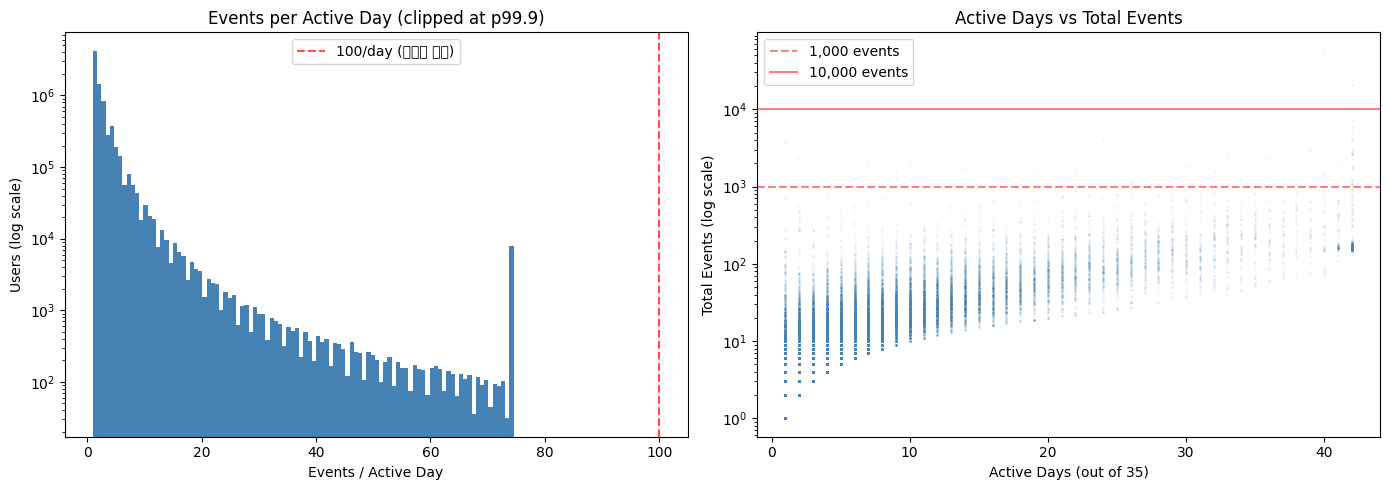

CPU times: user 1.22 s, sys: 582 ms, total: 1.81 s
Wall time: 1.96 s


In [3]:
%%time
# 일평균 이벤트 수 분포 시각화 (log-log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 (log scale)
axes[0].hist(
    user_stats["events_per_day"].clip(upper=user_stats["events_per_day"].quantile(0.999)),
    bins=100, color="steelblue", edgecolor="none", log=True,
)
axes[0].axvline(100, color="red", linestyle="--", alpha=0.7, label="100/day (임계값 후보)")
axes[0].set_title("Events per Active Day (clipped at p99.9)")
axes[0].set_xlabel("Events / Active Day")
axes[0].set_ylabel("Users (log scale)")
axes[0].legend()

# 활동 일수 vs 총 이벤트 수 scatter (샘플링)
sample = user_stats.sample(min(100_000, len(user_stats)), random_state=42)
axes[1].scatter(
    sample["active_days"], sample["total_events"],
    alpha=0.05, s=1, color="steelblue",
)
axes[1].set_yscale("log")
axes[1].set_title("Active Days vs Total Events")
axes[1].set_xlabel("Active Days (out of 35)")
axes[1].set_ylabel("Total Events (log scale)")
axes[1].axhline(1000, color="red", linestyle="--", alpha=0.5, label="1,000 events")
axes[1].axhline(10000, color="red", linestyle="-", alpha=0.5, label="10,000 events")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2-2. 복합 봇 스코어링

단일 기준이 아닌, 여러 신호를 결합한 봇 스코어를 만듭니다.

- **score_volume**: 일평균 이벤트 수가 p99 이상이면 1점
- **score_consistency**: 활동 일수가 상위 10% 이상이면 1점 (거의 매일 활동)
- **score_monotony**: 이벤트 타입이 1~2개뿐이면 1점 (단조로운 패턴)
- **score_intensity**: 총 이벤트 수가 p99.9 이상이면 1점

봇 스코어 = 4개 신호의 합 (0~4). 2점 이상이면 봇 의심.

In [4]:
%%time
# 봇 스코어 계산
p99_epd = user_stats["events_per_day"].quantile(0.99)
p90_days = user_stats["active_days"].quantile(0.90)
p999_total = user_stats["total_events"].quantile(0.999)

print(f"임계값:")
print(f"  일평균 이벤트 p99: {p99_epd:.1f}")
print(f"  활동 일수 p90: {p90_days:.0f}")
print(f"  총 이벤트 p99.9: {p999_total:,.0f}")

user_stats["score_volume"] = (user_stats["events_per_day"] >= p99_epd).astype(int)
user_stats["score_consistency"] = (user_stats["active_days"] >= p90_days).astype(int)
user_stats["score_monotony"] = (user_stats["n_event_types"] <= 2).astype(int)
user_stats["score_intensity"] = (user_stats["total_events"] >= p999_total).astype(int)

user_stats["bot_score"] = (
    user_stats["score_volume"]
    + user_stats["score_consistency"]
    + user_stats["score_monotony"]
    + user_stats["score_intensity"]
)

print(f"\n=== 봇 스코어 분포 ===")
score_dist = user_stats["bot_score"].value_counts().sort_index()
for score, cnt in score_dist.items():
    pct = cnt / len(user_stats) * 100
    print(f"  Score {score}: {cnt:>10,} ({pct:.2f}%)")

# 봇 의심 유저 (score >= 2)
bot_mask = user_stats["bot_score"] >= 2
n_bots = bot_mask.sum()
print(f"\n봇 의심 유저 (score >= 2): {n_bots:,} ({n_bots / len(user_stats) * 100:.2f}%)")
print(f"봇 의심 유저의 총 이벤트: {user_stats.loc[bot_mask, 'total_events'].sum():,}"
      f" ({user_stats.loc[bot_mask, 'total_events'].sum() / user_stats['total_events'].sum() * 100:.1f}%)")

임계값:
  일평균 이벤트 p99: 14.9
  활동 일수 p90: 8
  총 이벤트 p99.9: 729



=== 봇 스코어 분포 ===
  Score 0:    748,047 (9.47%)
  Score 1:  6,680,204 (84.53%)
  Score 2:    462,839 (5.86%)
  Score 3:      9,450 (0.12%)
  Score 4:      2,406 (0.03%)

봇 의심 유저 (score >= 2): 474,695 (6.01%)
봇 의심 유저의 총 이벤트: 90,341,966 (58.5%)
CPU times: user 298 ms, sys: 49.8 ms, total: 347 ms
Wall time: 367 ms


## 3. 봇 의심 유저 특성 분석

봇 스코어가 높은 유저들은 어떤 특징을 가지는지 살펴봅니다.

In [5]:
%%time
# 봇 vs 일반 유저 비교 통계
bot_users = user_stats[bot_mask]
human_users = user_stats[~bot_mask]

compare = pd.DataFrame({
    "봇 의심": [
        len(bot_users),
        bot_users["total_events"].median(),
        bot_users["events_per_day"].median(),
        bot_users["active_days"].median(),
        bot_users["n_event_types"].median(),
    ],
    "일반 유저": [
        len(human_users),
        human_users["total_events"].median(),
        human_users["events_per_day"].median(),
        human_users["active_days"].median(),
        human_users["n_event_types"].median(),
    ],
}, index=["유저 수", "총 이벤트 (중앙값)", "일평균 이벤트 (중앙값)", "활동 일수 (중앙값)", "이벤트 타입 수 (중앙값)"])

print("=== 봇 의심 vs 일반 유저 비교 ===")
print(compare.to_string())

=== 봇 의심 vs 일반 유저 비교 ===
                    봇 의심      일반 유저
유저 수            474695.0  7428251.0
총 이벤트 (중앙값)         29.0        3.0
일평균 이벤트 (중앙값)        2.6        1.5
활동 일수 (중앙값)         11.0        2.0
이벤트 타입 수 (중앙값)       2.0        1.0
CPU times: user 1.12 s, sys: 381 ms, total: 1.5 s
Wall time: 1.56 s


=== 이벤트 타입별 비율 비교 (봇 vs 일반) ===
                                 봇_이벤트수       봇_비율   일반_이벤트수      일반_비율
type                                                                   
PushEvent                      66612178  73.733372  42554193  66.297384
PullRequestEvent                6439345   7.127745   3404113   5.303444
CreateEvent                     5388384   5.964431   8020300  12.495241
DeleteEvent                     2740866   3.033879   2286613   3.562433
IssueCommentEvent               2709945   2.999652   1070902   1.668414
IssuesEvent                     2676023   2.962104   1661145   2.587984
PullRequestReviewCommentEvent   1563725   1.730895    625248   0.974106
PullRequestReviewEvent          1137010   1.258562    882092   1.374257
ReleaseEvent                     486738   0.538773    227693   0.354735
WatchEvent                       426911    0.47255   2527988   3.938484
ForkEvent                         72176   0.079892    556674   0.867271
CommitCommentEvent              

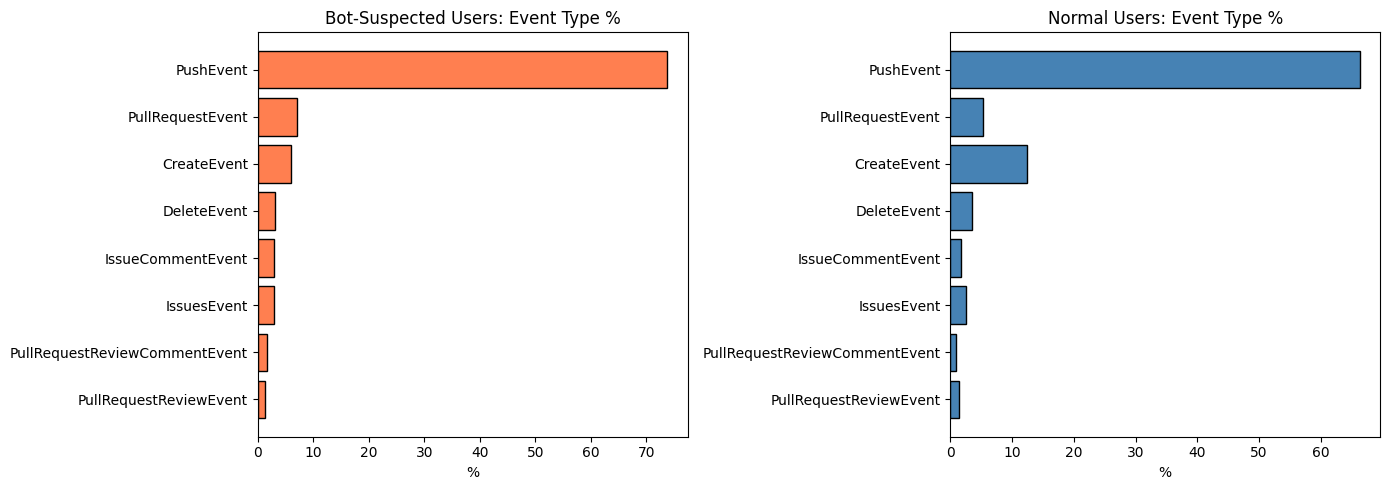

CPU times: user 4.7 s, sys: 1.29 s, total: 5.99 s
Wall time: 6.54 s


In [6]:
%%time
# 봇 의심 유저의 주요 이벤트 타입 분포
bot_ids = set(bot_users["actor_id"])
df_bot = df[df["actor_id"].isin(bot_ids)]
df_human = df[~df["actor_id"].isin(bot_ids)]

bot_type_dist = df_bot.groupby("type")["cnt"].sum().sort_values(ascending=False)
human_type_dist = df_human.groupby("type")["cnt"].sum().sort_values(ascending=False)

# 비율 비교
type_compare = pd.DataFrame({
    "봇_이벤트수": bot_type_dist,
    "봇_비율": bot_type_dist / bot_type_dist.sum() * 100,
    "일반_이벤트수": human_type_dist,
    "일반_비율": human_type_dist / human_type_dist.sum() * 100,
}).fillna(0)
type_compare = type_compare.sort_values("봇_이벤트수", ascending=False)

print("=== 이벤트 타입별 비율 비교 (봇 vs 일반) ===")
print(type_compare.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_types = type_compare.head(8).index.tolist()

axes[0].barh(top_types[::-1], type_compare.loc[top_types[::-1], "봇_비율"], color="coral", edgecolor="black")
axes[0].set_title("Bot-Suspected Users: Event Type %")
axes[0].set_xlabel("%")

axes[1].barh(top_types[::-1], type_compare.loc[top_types[::-1], "일반_비율"], color="steelblue", edgecolor="black")
axes[1].set_title("Normal Users: Event Type %")
axes[1].set_xlabel("%")

plt.tight_layout()
plt.show()

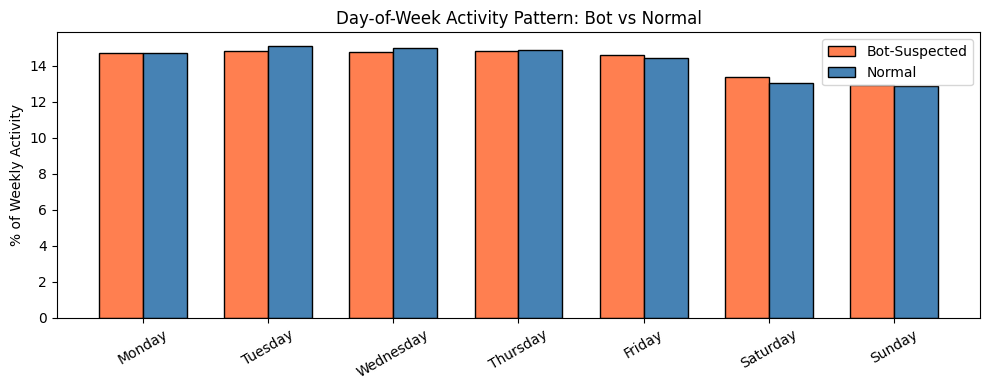

봇은 주말에도 활동량이 줄지 않으면 자동화 가능성이 높습니다.

봇 주말 비율: 26.3%
일반 주말 비율: 25.9%
CPU times: user 15.9 s, sys: 3.05 s, total: 18.9 s
Wall time: 20.6 s


In [7]:
%%time
# 봇 의심 유저의 활동 패턴 (요일별)
df_bot_daily = df_bot.groupby(df_bot["date"].dt.day_name())["actor_id"].nunique()
df_human_daily = df_human.groupby(df_human["date"].dt.day_name())["actor_id"].nunique()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
bot_weekday = df_bot_daily.reindex(weekday_order)
human_weekday = df_human_daily.reindex(weekday_order)

# 정규화 (각 그룹 내 비율)
bot_weekday_pct = bot_weekday / bot_weekday.sum() * 100
human_weekday_pct = human_weekday / human_weekday.sum() * 100

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(weekday_order))
w = 0.35
ax.bar(x - w/2, bot_weekday_pct.values, w, label="Bot-Suspected", color="coral", edgecolor="black")
ax.bar(x + w/2, human_weekday_pct.values, w, label="Normal", color="steelblue", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(weekday_order, rotation=30)
ax.set_ylabel("% of Weekly Activity")
ax.set_title("Day-of-Week Activity Pattern: Bot vs Normal")
ax.legend()
plt.tight_layout()
plt.show()

print("봇은 주말에도 활동량이 줄지 않으면 자동화 가능성이 높습니다.")
print(f"\n봇 주말 비율: {bot_weekday_pct[['Saturday', 'Sunday']].sum():.1f}%")
print(f"일반 주말 비율: {human_weekday_pct[['Saturday', 'Sunday']].sum():.1f}%")

In [8]:
%%time
# 봇 스코어별 top event type 분포
bot_score_types = user_stats.groupby("bot_score")["top_event_type"].value_counts().groupby(level=0).head(5)
print("=== 봇 스코어별 가장 많은 이벤트 타입 (Top 5) ===")
for score in sorted(user_stats["bot_score"].unique()):
    print(f"\n--- Score {score} ---")
    sub = bot_score_types.loc[score]
    for etype, cnt in sub.items():
        print(f"  {etype}: {cnt:,}")

# 봇 의심 상위 20명 프로파일
print("\n=== 봇 스코어 Top 20 유저 프로파일 ===")
top_bots = user_stats.nlargest(20, "total_events")[
    ["actor_id", "active_days", "total_events", "events_per_day",
     "n_event_types", "top_event_type", "bot_score"]
]
print(top_bots.to_string(index=False))

=== 봇 스코어별 가장 많은 이벤트 타입 (Top 5) ===

--- Score 0 ---
  PushEvent: 538,278
  CreateEvent: 80,518
  WatchEvent: 43,150
  PullRequestEvent: 30,475
  IssuesEvent: 15,697

--- Score 1 ---
  PushEvent: 4,203,207
  CreateEvent: 1,119,057
  WatchEvent: 840,786
  ForkEvent: 139,259
  IssuesEvent: 107,855

--- Score 2 ---
  PushEvent: 424,090
  WatchEvent: 16,683
  IssuesEvent: 11,689
  CreateEvent: 6,561
  IssueCommentEvent: 1,011

--- Score 3 ---
  PushEvent: 7,921
  IssuesEvent: 677
  CreateEvent: 285
  PullRequestEvent: 196
  IssueCommentEvent: 143

--- Score 4 ---
  PushEvent: 2,214
  IssueCommentEvent: 68
  CreateEvent: 47
  IssuesEvent: 24
  PullRequestEvent: 16

=== 봇 스코어 Top 20 유저 프로파일 ===
 actor_id  active_days  total_events  events_per_day  n_event_types                top_event_type  bot_score
 41898282           42      20158270   479958.809524             12                     PushEvent          3
 49699333           42       4269624   101657.714286              6              Pul

## 4. 봇 제거 전/후 주요 지표 비교

봇 의심 유저(score >= 2)를 제거하면 지표가 어떻게 변하는지 확인합니다.

비교 지표:
- **DAU** — 일별 활성 유저 수
- **WAU** — 주별 활성 유저 수 + 신규/복귀 비율
- **Weekly Cohort Retention** — 주간 코호트 잔존율
- **Stickiness (DAU/WAU)** — 습관성 지표

In [9]:
%%time
# 봇 제거 데이터셋
df_clean = df[~df["actor_id"].isin(bot_ids)].copy()

print(f"원본: {len(df):,} rows, {df['actor_id'].nunique():,} users")
print(f"정제: {len(df_clean):,} rows, {df_clean['actor_id'].nunique():,} users")
print(f"제거: {len(df) - len(df_clean):,} rows ({(len(df) - len(df_clean)) / len(df) * 100:.1f}%)")
print(f"       {df['actor_id'].nunique() - df_clean['actor_id'].nunique():,} users"
      f" ({(df['actor_id'].nunique() - df_clean['actor_id'].nunique()) / df['actor_id'].nunique() * 100:.2f}%)")

원본: 58,046,662 rows, 7,902,946 users


정제: 34,509,725 rows, 7,428,251 users
제거: 23,536,937 rows (40.5%)


       474,695 users (6.01%)
CPU times: user 15 s, sys: 2.19 s, total: 17.2 s
Wall time: 18.1 s


### 4-1. DAU 비교

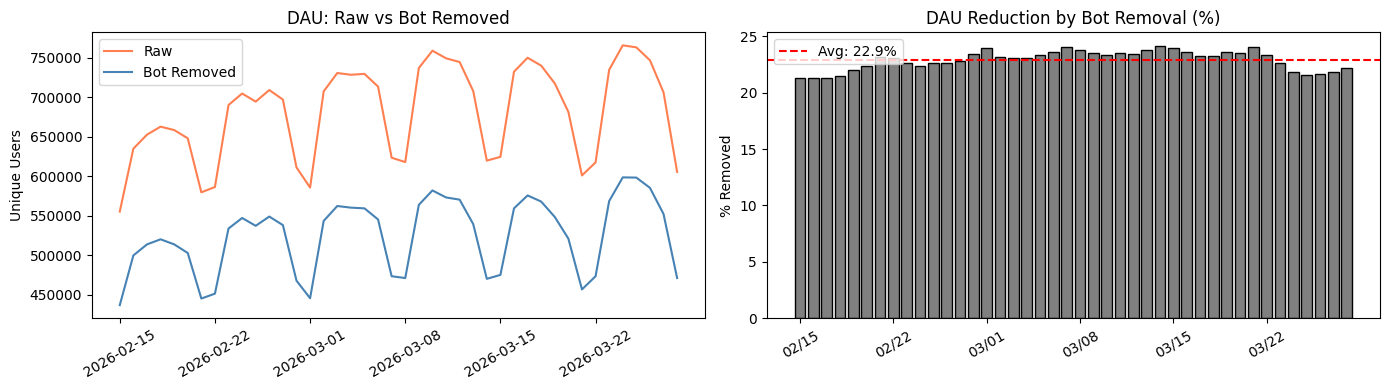

평균 DAU 변화: 681,284 → 525,196 (-22.9%)
CPU times: user 13 s, sys: 2.25 s, total: 15.3 s
Wall time: 16.1 s


In [10]:
%%time
dau_raw = daily_active_users(df)
dau_clean = daily_active_users(df_clean)

dau_compare = dau_raw.merge(dau_clean, on="date", suffixes=("_raw", "_clean"))
dau_compare["diff_pct"] = (dau_compare["dau_raw"] - dau_compare["dau_clean"]) / dau_compare["dau_raw"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# DAU 추이 비교
axes[0].plot(dau_compare["date"], dau_compare["dau_raw"], label="Raw", color="coral", linewidth=1.5)
axes[0].plot(dau_compare["date"], dau_compare["dau_clean"], label="Bot Removed", color="steelblue", linewidth=1.5)
axes[0].set_title("DAU: Raw vs Bot Removed")
axes[0].set_ylabel("Unique Users")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# 차이 비율
axes[1].bar(range(len(dau_compare)), dau_compare["diff_pct"], color="gray", edgecolor="black")
axes[1].axhline(dau_compare["diff_pct"].mean(), color="red", linestyle="--",
                label=f"Avg: {dau_compare['diff_pct'].mean():.1f}%")
axes[1].set_title("DAU Reduction by Bot Removal (%)")
axes[1].set_ylabel("% Removed")
axes[1].set_xticks(range(0, len(dau_compare), 7))
axes[1].set_xticklabels([d.strftime("%m/%d") for d in dau_compare["date"][::7]], rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"평균 DAU 변화: {dau_compare['dau_raw'].mean():,.0f} → {dau_compare['dau_clean'].mean():,.0f}"
      f" (-{dau_compare['diff_pct'].mean():.1f}%)")

### 4-2. Weekly Retention 비교

=== Raw Retention (%) ===
weeks_since      0     1     2     3     4     5
cohort_week                                     
02/15        100.0  46.2  39.7  36.7  33.9  32.5
02/22        100.0  32.5  26.6  23.4  22.0   0.0
03/01        100.0  29.3  22.1  19.8   0.0   0.0
03/08        100.0  26.6  20.1   0.0   0.0   0.0
03/15        100.0  26.3   0.0   0.0   0.0   0.0
03/22        100.0   0.0   0.0   0.0   0.0   0.0

=== Bot-Removed Retention (%) ===
weeks_since      0     1     2     3     4     5
cohort_week                                     
02/15        100.0  40.3  33.3  30.3  27.8  26.8
02/22        100.0  29.7  23.6  20.4  19.3   0.0
03/01        100.0  27.3  19.9  17.8   0.0   0.0
03/08        100.0  25.1  18.7   0.0   0.0   0.0
03/15        100.0  25.7   0.0   0.0   0.0   0.0
03/22        100.0   0.0   0.0   0.0   0.0   0.0

=== Difference (clean - raw, pp) ===
weeks_since    0     1     2     3     4     5
cohort_week                                   
02/15        0.0 -5.94 

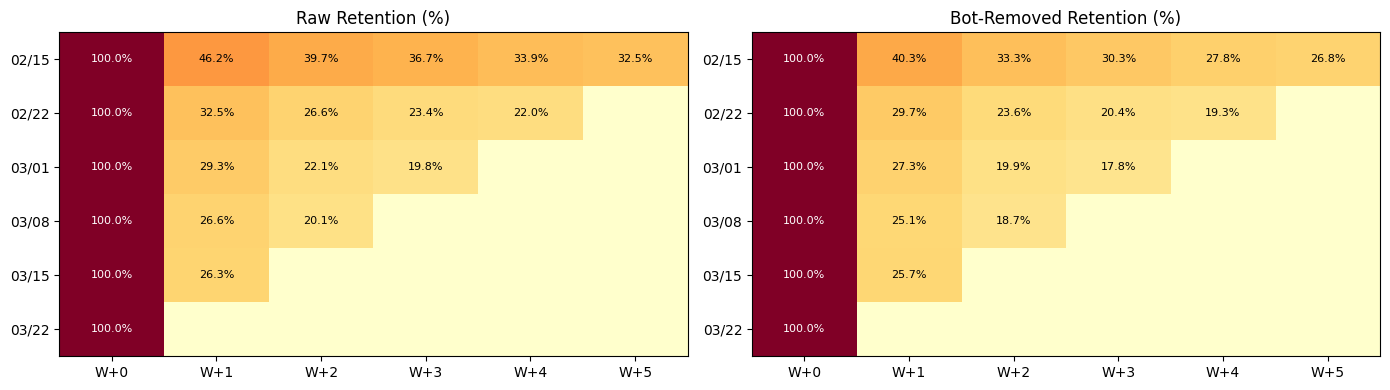

CPU times: user 38.2 s, sys: 6.68 s, total: 44.9 s
Wall time: 47.6 s


In [11]:
%%time
retention_raw = weekly_cohort_retention(df)
retention_clean = weekly_cohort_retention(df_clean)

print("=== Raw Retention (%) ===")
print((retention_raw * 100).round(1).to_string())
print("\n=== Bot-Removed Retention (%) ===")
print((retention_clean * 100).round(1).to_string())

# 차이
diff = (retention_clean - retention_raw) * 100
print("\n=== Difference (clean - raw, pp) ===")
print(diff.round(2).to_string())

# 히트맵 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title in [
    (axes[0], (retention_raw * 100).values, "Raw Retention (%)"),
    (axes[1], (retention_clean * 100).values, "Bot-Removed Retention (%)"),
]:
    im = ax.imshow(data, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if val > 0:
                color = "white" if val > 60 else "black"
                ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=8, color=color)
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels([f"W+{i}" for i in range(data.shape[1])])
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels(retention_raw.index)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### 4-3. WAU & Stickiness 비교

<timed exec>:59: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
<timed exec>:59: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


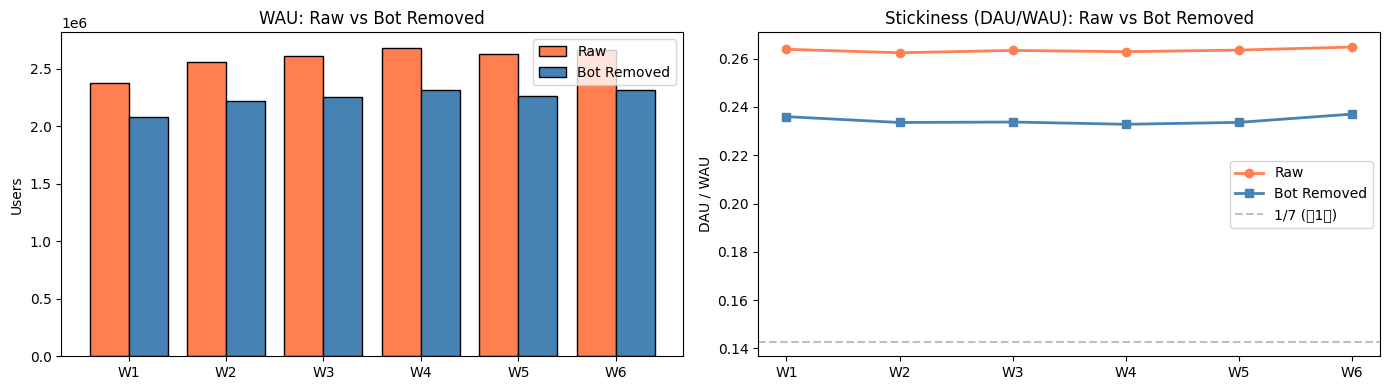

=== WAU 비교 ===
      week  wau_raw  wau_clean  diff_pct
2026-02-15  2376903    2077085 12.613809
2026-02-22  2554095    2216110 13.233063
2026-03-01  2612778    2254096 13.727994
2026-03-08  2681235    2312536 13.751089
2026-03-15  2626728    2264523 13.789208
2026-03-22  2664194    2318085 12.991134

=== Stickiness 비교 ===
      week  stickiness_raw  stickiness_clean   diff_pp
2026-02-15        0.263841          0.235955 -2.788546
2026-02-22        0.262395          0.233541 -2.885450
2026-03-01        0.263364          0.233732 -2.963182
2026-03-08        0.262856          0.232793 -3.006246
2026-03-15        0.263498          0.233577 -2.992087
2026-03-22        0.264759          0.237001 -2.775786
CPU times: user 41.6 s, sys: 4.2 s, total: 45.8 s
Wall time: 46.8 s


In [12]:
%%time
def calc_wau_stickiness(data, dau_df, weeks_list):
    """WAU와 Stickiness를 계산합니다."""
    first_week = data.groupby("actor_id")["week"].min()
    wau_data = []
    for w in weeks_list:
        active = set(data[data["week"] == w]["actor_id"].unique())
        new = set(first_week[first_week == w].index)
        returning = active - new
        wau_data.append({
            "week": w, "wau": len(active),
            "new_users": len(new), "returning_users": len(returning),
        })
    wau_df = pd.DataFrame(wau_data)
    wau_df["new_pct"] = wau_df["new_users"] / wau_df["wau"] * 100

    # Stickiness
    dau_df = dau_df.copy()
    dau_df["week"] = dau_df["date"].dt.to_period("W-SAT").dt.start_time
    stickiness_data = []
    for w in weeks_list:
        avg_dau = dau_df[dau_df["week"] == w]["dau"].mean()
        week_wau = wau_df[wau_df["week"] == w]["wau"].values[0]
        stickiness_data.append({
            "week": w, "avg_dau": avg_dau, "wau": week_wau,
            "stickiness": avg_dau / week_wau if week_wau > 0 else 0,
        })
    return wau_df, pd.DataFrame(stickiness_data)

# Raw
dau_raw_df = daily_active_users(df)
wau_raw, stick_raw = calc_wau_stickiness(df, dau_raw_df, weeks)

# Clean
dau_clean_df = daily_active_users(df_clean)
wau_clean, stick_clean = calc_wau_stickiness(df_clean, dau_clean_df, weeks)

# WAU 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = range(len(weeks))
axes[0].bar([i - 0.2 for i in x], wau_raw["wau"], 0.4, label="Raw", color="coral", edgecolor="black")
axes[0].bar([i + 0.2 for i in x], wau_clean["wau"], 0.4, label="Bot Removed", color="steelblue", edgecolor="black")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f"W{i+1}" for i in x])
axes[0].set_title("WAU: Raw vs Bot Removed")
axes[0].set_ylabel("Users")
axes[0].legend()

# Stickiness 비교
axes[1].plot(list(x), stick_raw["stickiness"], marker="o", label="Raw", color="coral", linewidth=2)
axes[1].plot(list(x), stick_clean["stickiness"], marker="s", label="Bot Removed", color="steelblue", linewidth=2)
axes[1].axhline(1/7, color="gray", linestyle="--", alpha=0.5, label="1/7 (주1회)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([f"W{i+1}" for i in x])
axes[1].set_title("Stickiness (DAU/WAU): Raw vs Bot Removed")
axes[1].set_ylabel("DAU / WAU")
axes[1].legend()

plt.tight_layout()
plt.show()

print("=== WAU 비교 ===")
wau_comp = wau_raw[["week", "wau"]].merge(wau_clean[["week", "wau"]], on="week", suffixes=("_raw", "_clean"))
wau_comp["diff_pct"] = (wau_comp["wau_raw"] - wau_comp["wau_clean"]) / wau_comp["wau_raw"] * 100
print(wau_comp.to_string(index=False))

print("\n=== Stickiness 비교 ===")
stick_comp = stick_raw[["week", "stickiness"]].merge(
    stick_clean[["week", "stickiness"]], on="week", suffixes=("_raw", "_clean")
)
stick_comp["diff_pp"] = (stick_comp["stickiness_clean"] - stick_comp["stickiness_raw"]) * 100
print(stick_comp.to_string(index=False))

### 4-4. 파레토 분석 비교

봇 제거 후 이벤트 집중도가 어떻게 변하는지 확인합니다.

<timed exec>:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


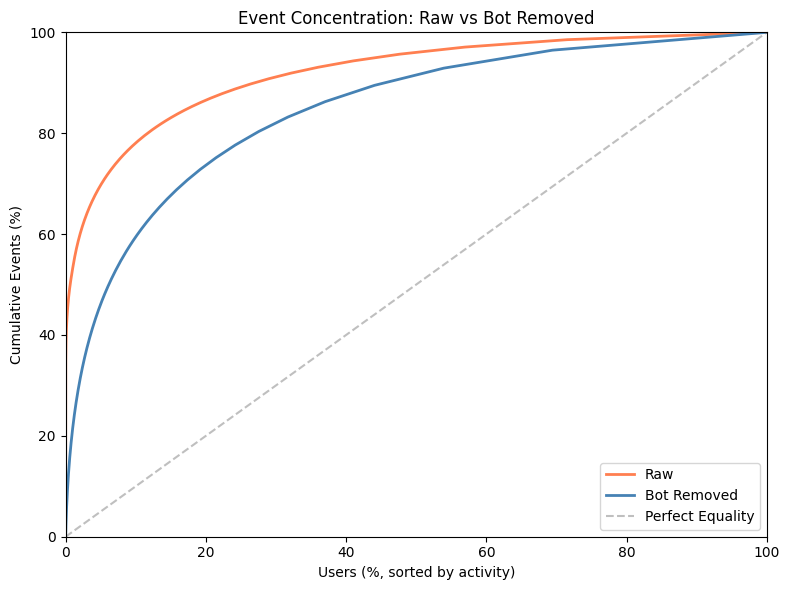

=== 파레토 비교 ===
 Top % |      Raw |    Clean |     Diff
----------------------------------------
    1% |    53.2% |    21.5% |   -31.7pp
    5% |    69.7% |    46.1% |   -23.6pp
   10% |    78.1% |    59.5% |   -18.6pp
   20% |    86.6% |    73.7% |   -12.9pp
CPU times: user 7min 14s, sys: 8.17 s, total: 7min 22s
Wall time: 7min 28s


In [13]:
%%time
# 봇 제거 후 유저별 이벤트 요약
clean_user_stats = user_activity_summary(df_clean)

def calc_pareto(events_series):
    """누적 이벤트 비율 계산."""
    sorted_events = events_series.sort_values(ascending=False).values
    total = sorted_events.sum()
    n = len(sorted_events)
    cumulative = np.cumsum(sorted_events) / total * 100
    user_pct = np.arange(1, n + 1) / n * 100
    return user_pct, cumulative, n

user_pct_raw, cum_raw, n_raw = calc_pareto(user_stats["total_events"])
user_pct_clean, cum_clean, n_clean = calc_pareto(clean_user_stats["total_events"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(user_pct_raw, cum_raw, color="coral", linewidth=2, label="Raw")
ax.plot(user_pct_clean, cum_clean, color="steelblue", linewidth=2, label="Bot Removed")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", alpha=0.5, label="Perfect Equality")
ax.set_xlabel("Users (%, sorted by activity)")
ax.set_ylabel("Cumulative Events (%)")
ax.set_title("Event Concentration: Raw vs Bot Removed")
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# 주요 포인트 비교
checkpoints = [1, 5, 10, 20]
print("=== 파레토 비교 ===")
print(f"{'Top %':>6} | {'Raw':>8} | {'Clean':>8} | {'Diff':>8}")
print("-" * 40)
for cp in checkpoints:
    idx_raw = int(n_raw * cp / 100) - 1
    idx_clean = int(n_clean * cp / 100) - 1
    raw_val = cum_raw[idx_raw]
    clean_val = cum_clean[idx_clean]
    print(f"{cp:>5}% | {raw_val:>7.1f}% | {clean_val:>7.1f}% | {clean_val - raw_val:>+7.1f}pp")

## 5. 봇 필터링 기준 민감도 분석

봇 스코어 임계값에 따라 제거되는 유저 수와 지표 변화를 비교합니다.
어떤 기준이 가장 적절한지 판단하기 위한 참고자료입니다.

=== 봇 필터링 민감도 분석 ===
 threshold  users_removed  users_removed_pct  events_removed_pct  W1→W2_retention
score >= 1        7154899          90.534580           94.415790        50.348193
score >= 2         474695           6.006558           58.462866        40.278708
score >= 3          11856           0.150020           41.354007        46.049251
score >= 4           2406           0.030444           10.165685        46.178151


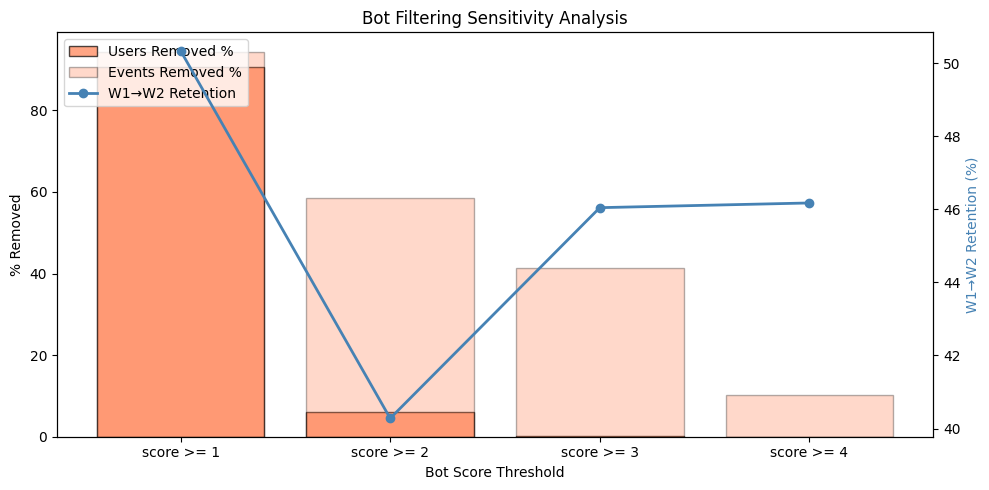

CPU times: user 1min 9s, sys: 15.2 s, total: 1min 24s
Wall time: 1min 30s


In [14]:
%%time
# 다양한 임계값에 대해 제거 규모와 W1→W2 retention 비교
results = []
for threshold in [1, 2, 3, 4]:
    mask = user_stats["bot_score"] >= threshold
    n_removed = mask.sum()
    pct_removed = n_removed / len(user_stats) * 100
    events_removed_pct = user_stats.loc[mask, "total_events"].sum() / user_stats["total_events"].sum() * 100

    # 해당 임계값으로 필터링한 데이터의 W1→W2 retention
    removed_ids = set(user_stats.loc[mask, "actor_id"])
    df_filtered = df[~df["actor_id"].isin(removed_ids)]
    ret = weekly_cohort_retention(df_filtered)
    w1_w2_ret = ret.iloc[0, 1] * 100 if ret.shape[1] > 1 else 0

    results.append({
        "threshold": f"score >= {threshold}",
        "users_removed": n_removed,
        "users_removed_pct": pct_removed,
        "events_removed_pct": events_removed_pct,
        "W1→W2_retention": w1_w2_ret,
    })

sensitivity = pd.DataFrame(results)

print("=== 봇 필터링 민감도 분석 ===")
print(sensitivity.to_string(index=False))

# 시각화
fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(sensitivity))
bars = ax1.bar(x, sensitivity["users_removed_pct"], color="coral", edgecolor="black", alpha=0.7, label="Users Removed %")
ax1.bar(x, sensitivity["events_removed_pct"], color="coral", edgecolor="black", alpha=0.3, label="Events Removed %")
ax1.set_xticks(list(x))
ax1.set_xticklabels(sensitivity["threshold"])
ax1.set_ylabel("% Removed")
ax1.set_xlabel("Bot Score Threshold")

ax2 = ax1.twinx()
ax2.plot(list(x), sensitivity["W1→W2_retention"], color="steelblue", marker="o", linewidth=2, label="W1→W2 Retention")
ax2.set_ylabel("W1→W2 Retention (%)", color="steelblue")

# 범례 통합
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Bot Filtering Sensitivity Analysis")
plt.tight_layout()
plt.show()

## 6. 정리 & 봇 필터링 재검토

기존 복합 스코어(score >= 2) 분석에서 한 가지 문제점이 드러났습니다:
- `score_monotony` (이벤트 타입 <= 2)가 전체 유저의 **84%** 를 잡아서 너무 느슨
- 이 때문에 복합 스코어가 사실상 "monotony + 아무거나 1개"가 되어 버림

아래에서 (1) 기존 요약을 유지하되, (2) **확실한 봇** 정의를 추가하고,
(3) 봇 제거가 실제 지표에 미치는 영향을 재검토합니다.

In [ ]:
%%time
# 기존 복합 스코어 요약 (참고용으로 유지)
print("=" * 60)
print("기존 복합 스코어 분석 요약")
print("=" * 60)

print(f"\n총 유저: {len(user_stats):,}")
print(f"봇 의심 유저 (score >= 2): {bot_mask.sum():,} ({bot_mask.sum() / len(user_stats) * 100:.2f}%)")
print(f"봇 의심 유저가 차지하는 이벤트 비율: "
      f"{user_stats.loc[bot_mask, 'total_events'].sum() / user_stats['total_events'].sum() * 100:.1f}%")

print("\n--- 봇 스코어 구성 ---")
print(f"  score_volume (일평균 이벤트 >= p99={p99_epd:.0f}): {user_stats['score_volume'].sum():,}")
print(f"  score_consistency (활동 일수 >= p90={p90_days:.0f}): {user_stats['score_consistency'].sum():,}")
print(f"  score_monotony (이벤트 타입 <= 2): {user_stats['score_monotony'].sum():,}")
print(f"  score_intensity (총 이벤트 >= p99.9={p999_total:,.0f}): {user_stats['score_intensity'].sum():,}")

monotony_pct = user_stats["score_monotony"].sum() / len(user_stats) * 100
print(f"\n⚠ score_monotony 해당 유저: {monotony_pct:.1f}% — 단독으로는 봇 신호로 부적절")

print(f"\n--- 봇 제거 전/후 주요 지표 ---")
print(f"  DAU: {dau_compare['dau_raw'].mean():,.0f} → {dau_compare['dau_clean'].mean():,.0f}"
      f" (-{dau_compare['diff_pct'].mean():.1f}%)")
print(f"  W1→W2 Retention: {retention_raw.iloc[0, 1]*100:.1f}% → {retention_clean.iloc[0, 1]*100:.1f}%")
print(f"  Stickiness: {stick_raw['stickiness'].mean():.1%} → {stick_clean['stickiness'].mean():.1%}")

### 6-1. "확실한 봇" 재정의

복합 스코어 대신, **행동 패턴으로 확실히 봇인 유저**를 식별합니다:

| 기준 | 정의 | 근거 |
|------|------|------|
| **CI/CD 봇** | 42일 중 40일+ 활동 AND PushEvent만 | 매일 빠짐없이 push만 하는 건 자동 배포 |
| **볼륨 극단치** | 총 이벤트 p99.99 이상 | 상위 0.01%는 사람이 만들 수 없는 수준 |

In [ ]:
%%time
# --- 확실한 봇 식별 ---

# 1) CI/CD 봇: 40일+ 활동 AND PushEvent만 (n_event_types == 1, top_event_type == PushEvent)
cicd_mask = (
    (user_stats["active_days"] >= 40)
    & (user_stats["n_event_types"] == 1)
    & (user_stats["top_event_type"] == "PushEvent")
)
n_cicd = cicd_mask.sum()

# 2) 볼륨 극단치: p99.99
p9999_total = user_stats["total_events"].quantile(0.9999)
volume_extreme_mask = user_stats["total_events"] >= p9999_total
n_volume_extreme = volume_extreme_mask.sum()

# 합집합
definite_bot_mask = cicd_mask | volume_extreme_mask
n_definite = definite_bot_mask.sum()

print("=" * 60)
print("확실한 봇 식별")
print("=" * 60)

print(f"\n1) CI/CD 봇 (40일+ 활동 & PushEvent만): {n_cicd:,}명")
print(f"   전체 유저 대비: {n_cicd / len(user_stats) * 100:.3f}%")
print(f"   이벤트 비중: {user_stats.loc[cicd_mask, 'total_events'].sum() / user_stats['total_events'].sum() * 100:.1f}%")

print(f"\n2) 볼륨 극단치 (총 이벤트 >= {p9999_total:,.0f}, p99.99): {n_volume_extreme:,}명")
print(f"   이벤트 비중: {user_stats.loc[volume_extreme_mask, 'total_events'].sum() / user_stats['total_events'].sum() * 100:.1f}%")

# 상위 4명 확인
top4 = user_stats.nlargest(4, "total_events")[["actor_id", "total_events", "active_days", "n_event_types", "top_event_type"]]
top4_event_pct = top4["total_events"].sum() / user_stats["total_events"].sum() * 100
print(f"\n   참고: 상위 4명이 전체 이벤트의 {top4_event_pct:.1f}% 차지")
print(top4.to_string(index=False))

# 만 건 이상 유저
over_10k_mask = user_stats["total_events"] >= 10_000
n_over_10k = over_10k_mask.sum()
over_10k_pct = user_stats.loc[over_10k_mask, "total_events"].sum() / user_stats["total_events"].sum() * 100
print(f"\n   참고: 만 건+ 유저 {n_over_10k:,}명 → 전체 이벤트의 {over_10k_pct:.1f}%")

print(f"\n합집합 (확실한 봇): {n_definite:,}명 ({n_definite / len(user_stats) * 100:.3f}%)")
print(f"이벤트 비중: {user_stats.loc[definite_bot_mask, 'total_events'].sum() / user_stats['total_events'].sum() * 100:.1f}%")

### 6-2. 봇을 잡아야 할까? — 비율 지표 vs 절대량 지표

봇이 **매주 꾸준히** 활동하면 Retention 같은 비율 지표에서는 분자(잔존 유저)와 분모(코호트)에 동시에 포함됩니다.
따라서 봇을 제거해도 비율이 크게 변하지 않을 수 있습니다.

아래에서 확실한 봇(p99.99 기준)을 제거한 전/후 Retention을 비교합니다.

In [ ]:
%%time
# --- 확실한 봇 제거 전/후 비교 ---

definite_bot_ids = set(user_stats.loc[definite_bot_mask, "actor_id"])
df_no_definite_bots = df[~df["actor_id"].isin(definite_bot_ids)]

print("=" * 60)
print("확실한 봇 제거 전/후 지표 비교")
print("=" * 60)

# DAU 비교
dau_nobot = df_no_definite_bots.groupby("date")["actor_id"].nunique().reset_index(name="dau")
dau_merged = dau_raw_df.merge(dau_nobot, on="date", suffixes=("_raw", "_nobot"))
dau_merged["diff_pct"] = (dau_merged["dau_raw"] - dau_merged["dau_nobot"]) / dau_merged["dau_raw"] * 100

print(f"\n--- DAU ---")
print(f"  원본:       {dau_merged['dau_raw'].mean():,.0f}")
print(f"  봇 제거 후: {dau_merged['dau_nobot'].mean():,.0f} (-{dau_merged['diff_pct'].mean():.1f}%)")

# Retention 비교
retention_nobot = weekly_cohort_retention(df_no_definite_bots)
print(f"\n--- W1→W2 Retention ---")
print(f"  원본:       {retention_raw.iloc[0, 1]*100:.1f}%")
print(f"  봇 제거 후: {retention_nobot.iloc[0, 1]*100:.1f}%")
print(f"  차이:       {(retention_nobot.iloc[0, 1] - retention_raw.iloc[0, 1])*100:+.1f}pp")

# 이벤트 수 비교
total_events_raw = len(df)
total_events_nobot = len(df_no_definite_bots)
events_diff_pct = (total_events_raw - total_events_nobot) / total_events_raw * 100
print(f"\n--- 총 이벤트 수 ---")
print(f"  원본:       {total_events_raw:,}")
print(f"  봇 제거 후: {total_events_nobot:,} (-{events_diff_pct:.1f}%)")

# 시각화: Retention 비교 바 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: DAU 비교
axes[0].plot(dau_merged["date"], dau_merged["dau_raw"], label="Raw", color="coral", linewidth=1.5)
axes[0].plot(dau_merged["date"], dau_merged["dau_nobot"], label="Definite Bot Removed", color="steelblue", linewidth=1.5)
axes[0].set_title("DAU: Raw vs Definite Bot Removed")
axes[0].set_ylabel("DAU")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# 오른쪽: Retention 비교
weeks = retention_raw.columns[:4]
ret_raw_vals = [retention_raw.iloc[0, i] * 100 for i in range(len(weeks))]
ret_nobot_vals = [retention_nobot.iloc[0, i] * 100 for i in range(len(weeks))]

x = range(len(weeks))
w = 0.35
axes[1].bar([i - w/2 for i in x], ret_raw_vals, w, label="Raw", color="coral", edgecolor="black")
axes[1].bar([i + w/2 for i in x], ret_nobot_vals, w, label="Definite Bot Removed", color="steelblue", edgecolor="black")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([f"W1→W{i+2}" for i in range(len(weeks))])
axes[1].set_ylabel("Retention (%)")
axes[1].set_title("Cohort Retention: Raw vs Definite Bot Removed")
axes[1].legend()

for i in x:
    diff = ret_nobot_vals[i] - ret_raw_vals[i]
    axes[1].annotate(f"{diff:+.1f}pp", (i + w/2, ret_nobot_vals[i] + 0.5),
                     ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

### 6-3. 결론: 분석 목적에 따라 필터링 여부 결정

| 지표 유형 | 봇 영향 | 필터링 필요? |
|-----------|---------|-------------|
| **Retention, Stickiness** (비율) | 분자/분모에 동시 포함 → 상쇄 | 거의 불필요 |
| **DAU, WAU** (절대량) | 봇이 매일 활동 → 과대 집계 | 필요 |
| **이벤트 수, 트래픽** (절대량) | 상위 0.01%가 전체의 ~18% | 필요 |

**왜 Retention은 안 변할까?**
- 봇은 매주 꾸준히 활동 → W1 코호트에 들어가면 W2, W3에도 계속 나타남
- 분모(코호트 크기)와 분자(잔존 유저)에 동시 포함되어 비율이 상쇄됨
- 반면 DAU는 절대 수치이므로 봇 수만큼 그대로 과대 집계

**권장 접근:**
- Retention 분석 → 봇 필터링 없이 진행해도 무방
- DAU/이벤트 수 기반 분석 → 확실한 봇(CI/CD + 볼륨 극단치) 제거 권장
- 복합 스코어(score >= 2)는 monotony의 느슨함 때문에 과잉 제거 위험 있음